**Author:** Dr. Alexis Hucteau  
**Contact:** [LinkedIn](https://www.linkedin.com/in/alexis-hucteau/) [Malt](https://www.malt.fr/profile/alexishucteau1)  
**Date:** May 2026

### Licensing Notice
- **Code:** This work is licensed under the [GNU GPL v3](https://www.gnu.org/licenses/gpl-3.0.html).
- **Analysis & Visualizations:** The interpretive content of this notebook is licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).

*Copyright (c) 2026 Alexis Hucteau. All rights reserved.*

In [1]:
import pandas as pd
import numpy as np

premier_tour = pd.read_parquet('../data/processed/premier_tour_cleaned.parquet')
deuxieme_tour = pd.read_parquet('../data/processed/deuxieme_tour_cleaned.parquet')

# Analyse du premier tour

In [2]:
display(premier_tour.head())

,Tour,bureau,inscrits,abstentions,votants,votants_ap_emargement,blancs,nuls,exprimes,Briançon,...,Meilhac,Piquemal,Pedinotti,adresse,Geo_Point,Geo_Shape,gml_id,infobulle,oid,Nom
0,1,0005,957,401,556,556,4,2,550,121,...,9,208,7,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00<\xa5\x9c\x8e\x81\xff\xf...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.385,Bureau de vote : 005\nLieu de vote : Salle Bar...,385,Salle Barcelone
1,1,0007,892,384,508,508,2,1,505,98,...,2,134,7,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00V\xf3m\r\xae\x1a\xf7?\xf...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.417,Bureau de vote : 007\nLieu de vote : Salle Bar...,417,Salle Barcelone
2,1,0014,1159,513,646,646,3,3,640,165,...,6,245,6,60 rue Matabiau,b'\x01\x01\x00\x00\x00\xe9P\xc9\xe7\xac:\xf7?L...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.516,Bureau de vote : 014\nLieu de vote : École élé...,516,École élémentaire Bayard
3,1,0017,1131,362,769,769,3,1,765,223,...,10,229,10,60 rue Matabiau,b'\x01\x01\x00\x00\x00\xd8)\xe8G\xf8&\xf7?\xb8...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.486,Bureau de vote : 017\nLieu de vote : École élé...,486,École élémentaire Bayard
4,1,0018,781,328,453,453,4,2,447,126,...,8,122,4,6 rue du Lieutenant Colonnel Pélissier,b'\x01\x01\x00\x00\x00\xff\xf2^\xebH:\xf7?\xcf...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.463,Bureau de vote : 018\nLieu de vote : Salle Osè...,463,Salle Osète


In [3]:
emargement = premier_tour['votants'] == premier_tour['votants_ap_emargement']

emargement.value_counts()

display(premier_tour.loc[~emargement, ['bureau', 'votants', 'votants_ap_emargement']])


,bureau,votants,votants_ap_emargement
7,0029,730,731
13,0060,669,668
62,0022,620,621
63,0023,636,635
70,0048,791,790
74,0079,701,697
93,0167,553,552
96,0209,603,604
97,0210,677,676
106,0240,428,429


Text(0.5, 1.0, 'Taux de participation au premier Tour à travers les différents bureaux de vote')

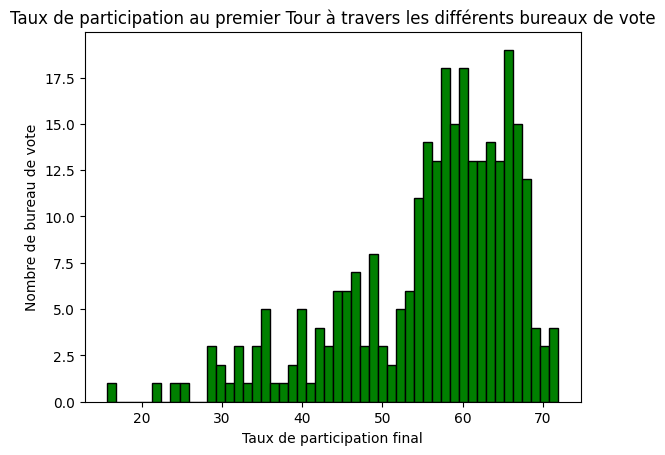

In [4]:
import matplotlib.pyplot as plt

premier_tour['tx_participation'] = (premier_tour['votants'] / premier_tour['inscrits'])*100
n, bins, patches = plt.hist(premier_tour['tx_participation'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de participation final')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de participation au premier Tour à travers les différents bureaux de vote')

Text(0.5, 1.0, 'Taux de votes blancs et nuls au premier Tour à travers les différents bureaux de vote')

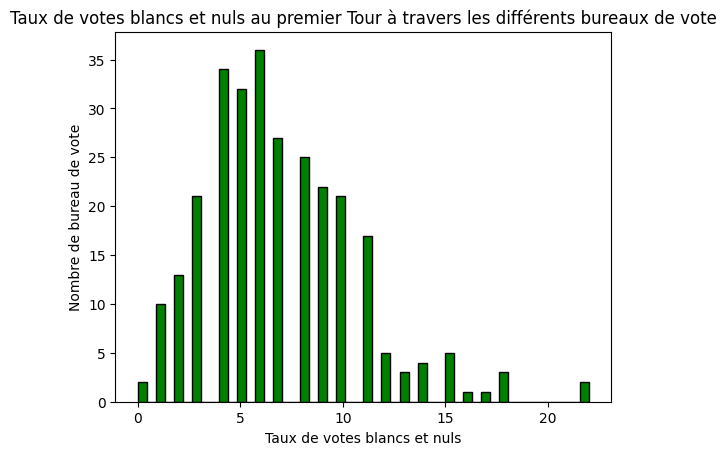

In [5]:
premier_tour['tx_nuls_blc'] = premier_tour['blancs'] + premier_tour['nuls']
n, bins, patches = plt.hist(premier_tour['tx_nuls_blc'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de votes blancs et nuls')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de votes blancs et nuls au premier Tour à travers les différents bureaux de vote')

In [6]:
votants_premier_tour = premier_tour['exprimes'].sum()

scores_vivre_mieux = [(premier_tour['Briançon'] / premier_tour['votants']) *100, premier_tour['Briançon']]
scores_NPA = [(premier_tour['Scalli'] / premier_tour['votants']) *100, premier_tour['Scalli']]
scores_Lutte = [(premier_tour['Adrada'] / premier_tour['votants']) *100, premier_tour['Adrada']]
scores_TRAVAILLEURS  = [(premier_tour['Menendez'] / premier_tour['votants']) *100, premier_tour['Menendez']]
scores_RN = [(premier_tour['Leonardelli'] / premier_tour['votants']) *100, premier_tour['Leonardelli']]
scores_RECONQUETE  = [(premier_tour['Cottrel'] / premier_tour['votants']) *100, premier_tour['Cottrel']]
scores_NOUVEL_AIR = [(premier_tour['Meilhac'] / premier_tour['votants']) *100, premier_tour['Meilhac']]
scores_RV = [(premier_tour['Pedinotti'] / premier_tour['votants']) *100, premier_tour['Pedinotti']]
scores_Moudenc = [(premier_tour['Moudenc'] / premier_tour['votants']) *100, premier_tour['Moudenc']]
scores_Piquemal = [(premier_tour['Piquemal'] / premier_tour['votants']) *100, premier_tour['Piquemal']]

scores_gauche = [scores_vivre_mieux[0] + scores_Piquemal[0] + scores_RV[0] + scores_TRAVAILLEURS[0] + scores_Lutte[0] + scores_NPA[0], 
                 scores_vivre_mieux[1] + scores_Piquemal[1] + scores_RV[1] + scores_TRAVAILLEURS[1] + scores_Lutte[1] + scores_NPA[1]]
scores_union_deuxieme_tour = [scores_vivre_mieux[0] + scores_Piquemal[0], scores_vivre_mieux[1] + scores_Piquemal[1]]
scores_droite = [scores_Moudenc[0] + scores_RN[0] + scores_RECONQUETE[0], scores_Moudenc[1] + scores_RN[1] + scores_RECONQUETE[1]]
scores_premier_tour = {'scores_vivre_mieux' : scores_vivre_mieux, 
                       'scores_RN' : scores_RN,
                        'scores_Moudenc' : scores_Moudenc, 'scores_Piquemal' : scores_Piquemal, 
                        'scores_gauche' : scores_gauche, 'scores_droite' : scores_droite, 'scores_union_deuxieme_tour' : scores_union_deuxieme_tour
}

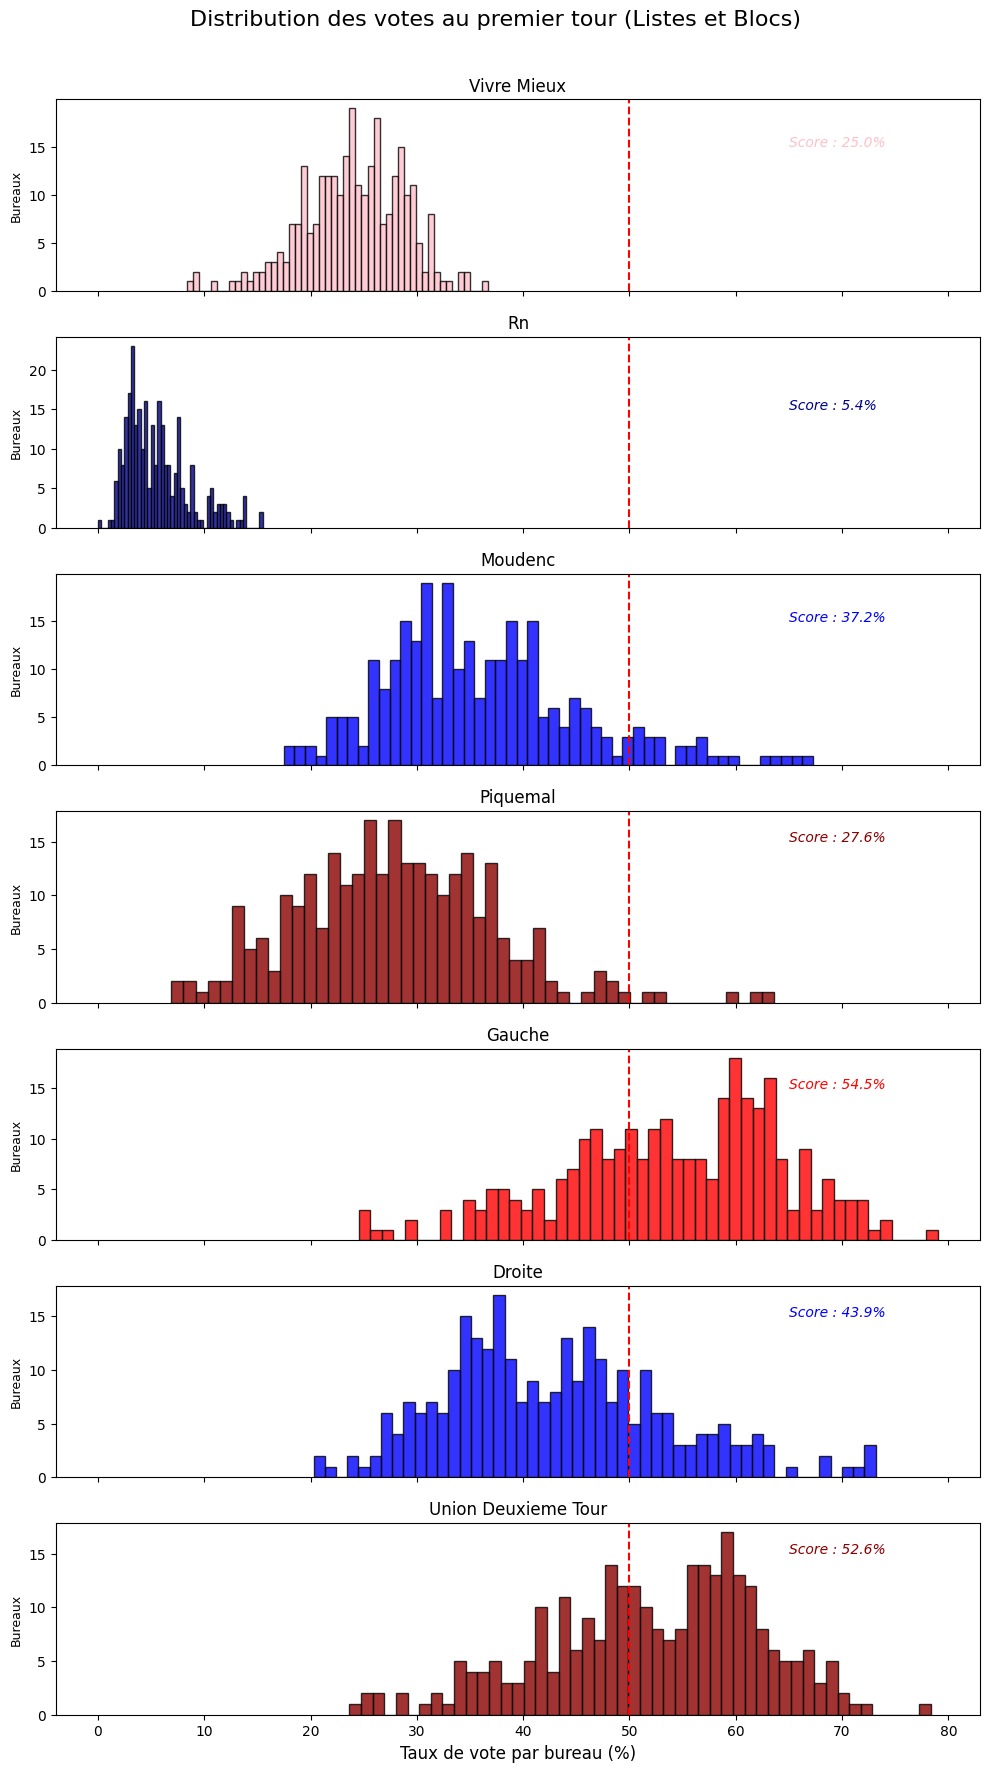

In [7]:
n_graphs = len(scores_premier_tour)

fig, axes = plt.subplots(nrows=n_graphs, ncols=1, figsize=(10, 2.5 * n_graphs), sharex=True)

colors = ['pink', 'darkblue', 'blue', 'darkred', 'red', 'blue', 'darkred']

for ax, (nom_variable, donnees), color in zip(axes, scores_premier_tour.items(), colors):
    
    ax.hist(donnees[0], bins=50, edgecolor='black', alpha=0.8, facecolor = color)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    score = 100*(donnees[1].sum()) / votants_premier_tour
   
    texte_info = f"Score : {score:.1f}%"
    
    ax.text(x=65, y=15, s=texte_info, 
            fontsize=10, 
            color=color,
            style='italic') 
    
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50%')

axes[-1].set_xlabel('Taux de vote par bureau (%)', fontsize=12)

fig.suptitle('Distribution des votes au premier tour (Listes et Blocs)', fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/scores_listes_premier_tour.png')

plt.show()

# Analyse du Second tour

In [8]:
display(deuxieme_tour.head())

,Tour,bureau,inscrits,abstentions,votants,votants_ap_emargement,blancs,nuls,exprimes,Moudenc,Piquemal,adresse,Geo_Point,Geo_Shape,gml_id,infobulle,oid,Nom
0,2,0002,901,264,637,637,10,3,624,345,279,Place du Capitole,b'\x01\x01\x00\x00\x00\x87Z\xa4&\xee\x16\xf7?*...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.321,Bureau de vote : 002\nLieu de vote : Capitole ...,321,Capitole – Salle des Commissions
1,2,0005,956,335,621,621,15,4,602,292,310,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00<\xa5\x9c\x8e\x81\xff\xf...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.385,Bureau de vote : 005\nLieu de vote : Salle Bar...,385,Salle Barcelone
2,2,0006,925,325,600,600,11,3,586,274,312,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00H\x8e#C\x1e\x0f\xf7?\xbe...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.510,Bureau de vote : 006\nLieu de vote : Salle Bar...,510,Salle Barcelone
3,2,0010,1107,334,773,773,14,6,753,403,350,13 boulevard d'Arcole,b'\x01\x01\x00\x00\x00\xa6\x03\xd8\xad\\\x06\x...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.430,Bureau de vote : 010\nLieu de vote : École élé...,430,École élémentaire du Nord
4,2,0013,1157,401,756,756,10,6,740,346,394,60 rue Matabiau,b'\x01\x01\x00\x00\x00\x90j\x80\x02\xc7.\xf7?8...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.557,Bureau de vote : 013\nLieu de vote : École élé...,557,École élémentaire Bayard


In [9]:
emargement = deuxieme_tour['votants'] == deuxieme_tour['votants_ap_emargement']

emargement.value_counts()

display(deuxieme_tour.loc[~emargement, ['bureau', 'votants', 'votants_ap_emargement']])

,bureau,votants,votants_ap_emargement
18,0057,673,672
20,0060,766,767
46,0204,382,381
53,0238,661,657
54,0239,599,598
63,0001,686,687
64,0003,538,537
77,0053,775,776
94,0136,621,622
95,0138,762,761


Text(0.5, 1.0, 'Taux de participation au deuxième Tour à travers les différents bureaux de vote')

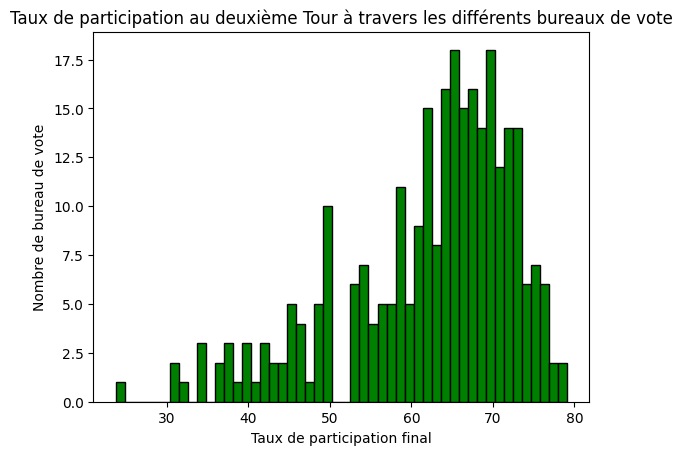

In [10]:
deuxieme_tour['tx_participation'] = (deuxieme_tour['votants'] / deuxieme_tour['inscrits'])*100
n, bins, patches = plt.hist(deuxieme_tour['tx_participation'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de participation final')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de participation au deuxième Tour à travers les différents bureaux de vote')

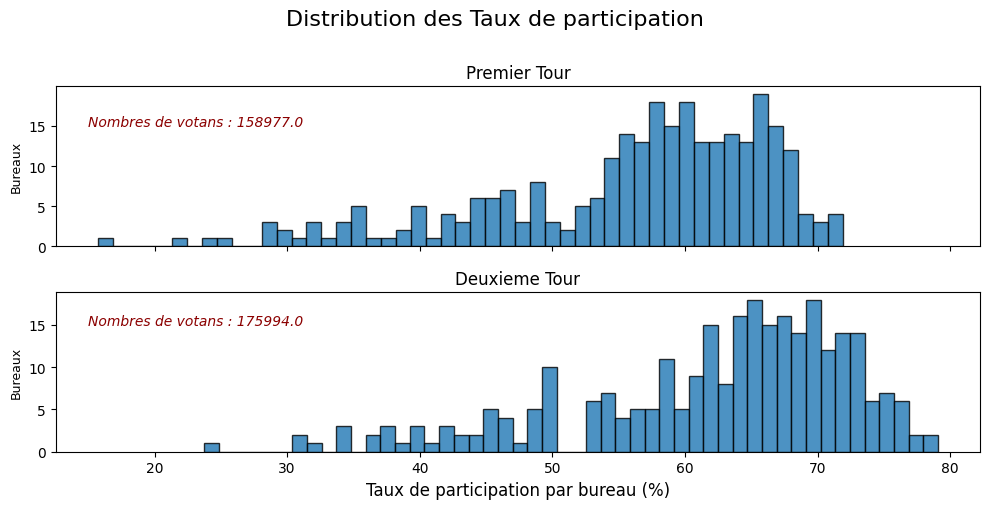

In [11]:
participation_premier = premier_tour['votants'].sum()
participation_deuxieme = deuxieme_tour['votants'].sum()

participation = [participation_premier, participation_deuxieme]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 2.5 * 2), sharex=True)

for ax, (nom_variable, donnees), partic in zip(axes, {'premier_tour' : premier_tour['tx_participation'], 
                                              'deuxieme_tour' : deuxieme_tour['tx_participation']}.items(), participation):
    
    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    texte_info = f"Nombres de votans : {partic:.1f}"
    
    ax.text(x=15, y=15, s=texte_info, 
            fontsize=10, 
            color='darkred',
            style='italic') 

    
    
axes[-1].set_xlabel('Taux de participation par bureau (%)', fontsize=12)

fig.suptitle('Distribution des Taux de participation', fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/Taux_participation_premier_tour.png')

plt.show()

Text(0.5, 1.0, 'Taux de votes blancs et nuls au deuxième Tour à travers les différents bureaux de vote')

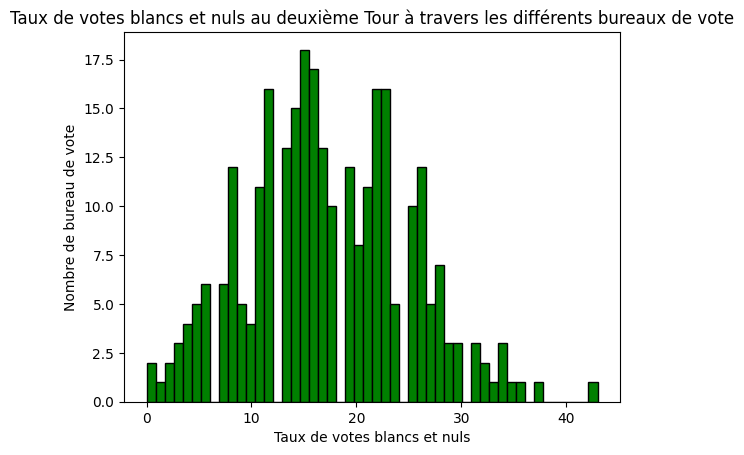

In [12]:
deuxieme_tour['tx_nuls_blc'] = deuxieme_tour['blancs'] + deuxieme_tour['nuls']
n, bins, patches = plt.hist(deuxieme_tour['tx_nuls_blc'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de votes blancs et nuls')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de votes blancs et nuls au deuxième Tour à travers les différents bureaux de vote')

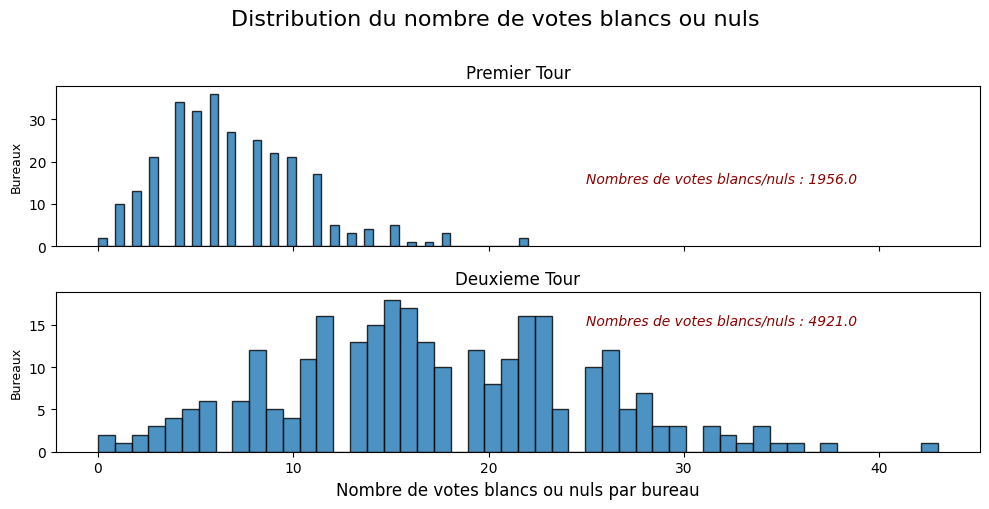

In [13]:
votes_blancs_nuls_premier = premier_tour['tx_nuls_blc'].sum()
votes_blancs_nuls_deuxieme = deuxieme_tour['tx_nuls_blc'].sum()

votes_blancs_nuls = [votes_blancs_nuls_premier, votes_blancs_nuls_deuxieme]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 2.5 * 2), sharex=True)

for ax, (nom_variable, donnees), votes_blancs in zip(axes, {'premier_tour' : premier_tour['tx_nuls_blc'], 
                                              'deuxieme_tour' : deuxieme_tour['tx_nuls_blc']}.items(), votes_blancs_nuls):
    
    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)
    
    texte_info = f"Nombres de votes blancs/nuls : {votes_blancs:.1f}"
    
    ax.text(x=25, y=15, s=texte_info, 
            fontsize=10, 
            color='darkred',
            style='italic') 
    
axes[-1].set_xlabel('Nombre de votes blancs ou nuls par bureau', fontsize=12)

fig.suptitle('Distribution du nombre de votes blancs ou nuls', fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/Votes_blancs_nuls_premier_tour.png')

plt.show()

In [14]:
votants_deuxieme_tour = deuxieme_tour['exprimes'].sum()

scores_Moudenc = [(deuxieme_tour['Moudenc'] / deuxieme_tour['votants']) *100, deuxieme_tour['Moudenc']]
scores_Piquemal = [(deuxieme_tour['Piquemal'] / deuxieme_tour['votants']) *100, deuxieme_tour['Piquemal']]

scores_deuxieme_tour = {'scores_Piquemal' : scores_Piquemal,
                        'scores_Moudenc' : scores_Moudenc}

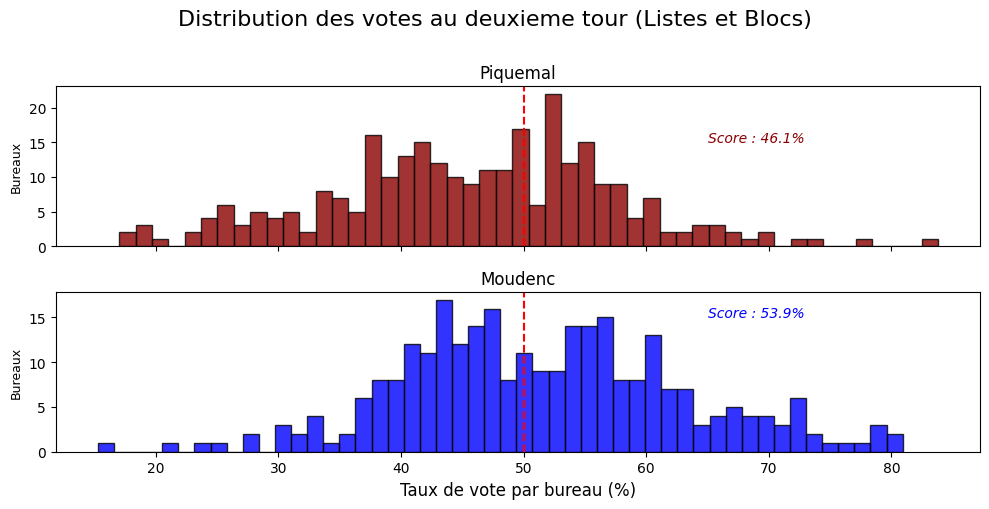

In [15]:
n_graphs = len(scores_deuxieme_tour)

fig, axes = plt.subplots(nrows=n_graphs, ncols=1, figsize=(10, 2.5 * n_graphs), sharex=True)

colors = ['darkred', 'blue']

for ax, (nom_variable, donnees), color in zip(axes, scores_deuxieme_tour.items(), colors):
    
    ax.hist(donnees[0], bins=50, edgecolor='black', alpha=0.8, facecolor = color)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    score = 100*(donnees[1].sum()) / votants_deuxieme_tour
   
    texte_info = f"Score : {score:.1f}%"
    
    ax.text(x=65, y=15, s=texte_info, 
            fontsize=10, 
            color=color,
            style='italic') 
    
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50%')

axes[-1].set_xlabel('Taux de vote par bureau (%)', fontsize=12)

fig.suptitle('Distribution des votes au deuxieme tour (Listes et Blocs)', fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/scores_listes_second_tour.png')

plt.show()

# Analyse Multivariée et Clustering (Typologie des bureaux)

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

liste_bureau = premier_tour['bureau']

df = premier_tour.drop(columns = ['Tour', 'bureau', 'votants', 'votants_ap_emargement', 'adresse', 'Geo_Point', 'Geo_Shape',
       'gml_id', 'infobulle', 'oid', 'Nom', 'tx_participation', 'tx_nuls_blc', 'exprimes'])

df['blc_nuls'] = df['blancs'] + df['nuls']

df = df.drop(columns=['blancs', 'nuls'])

listes_candidates = df.columns[1:]

df[listes_candidates] = df[listes_candidates].div(df['inscrits'], axis=0) * 100

df = df.drop(columns=['inscrits'])

In [17]:
display(df.head())

,abstentions,Briançon,Scalli,Adrada,Menendez,Moudenc,Leonardelli,Cottrel,Meilhac,Piquemal,Pedinotti,blc_nuls
0,41.901776,12.643678,0.000000,0.104493,0.313480,19.331243,1.358412,0.313480,0.940439,21.734587,0.731452,0.626959
1,43.049327,10.986547,0.000000,0.112108,0.000000,26.121076,1.681614,1.681614,0.224215,15.022422,0.784753,0.336323
2,44.262295,14.236411,0.172563,0.690250,0.172563,14.926661,2.329594,0.517688,0.517688,21.138913,0.517688,0.517688
3,32.007073,19.717065,0.000000,0.176835,0.000000,24.403183,0.707339,0.618921,0.884173,20.247569,0.884173,0.353669
4,41.997439,16.133163,0.000000,0.256082,0.000000,18.693982,3.841229,1.152369,1.024328,15.620999,0.512164,0.768246


Variance expliquée par axe : [24.57812458 19.68322513]


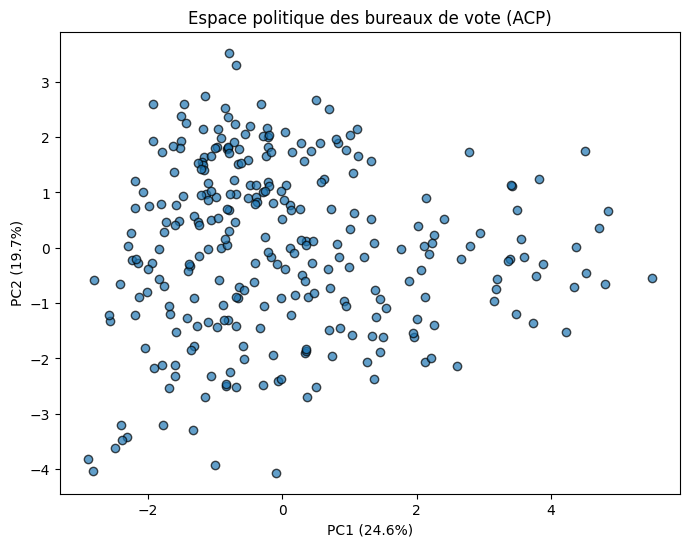

In [18]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par axe : {pca.explained_variance_ratio_ * 100}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Espace politique des bureaux de vote (ACP)')
plt.show()

In [19]:
colonnes_totales = df.columns

df_loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=colonnes_totales  
)

print("--- Contributions à l'axe PC1 ---")
display(df_loadings.sort_values(by='PC1', ascending=False)['PC1'])

print("\n--- Contributions à l'axe PC2 ---")
display(df_loadings.sort_values(by='PC2', ascending=False)['PC2'])

--- Contributions à l'axe PC1 ---


abstentions    0.552484
Menendez       0.231086
Scalli         0.094114
Adrada         0.072624
Leonardelli    0.028329
blc_nuls       0.004597
Pedinotti     -0.049740
Piquemal      -0.072108
Cottrel       -0.269341
Meilhac       -0.358906
Moudenc       -0.441584
Briançon      -0.471569
Name: PC1, dtype: float64


--- Contributions à l'axe PC2 ---


Piquemal       0.568416
Pedinotti      0.393215
Briançon       0.280186
Adrada         0.178361
Menendez       0.086013
Scalli         0.067721
Meilhac        0.043427
abstentions   -0.095692
blc_nuls      -0.108361
Moudenc       -0.317125
Cottrel       -0.347409
Leonardelli   -0.394888
Name: PC2, dtype: float64

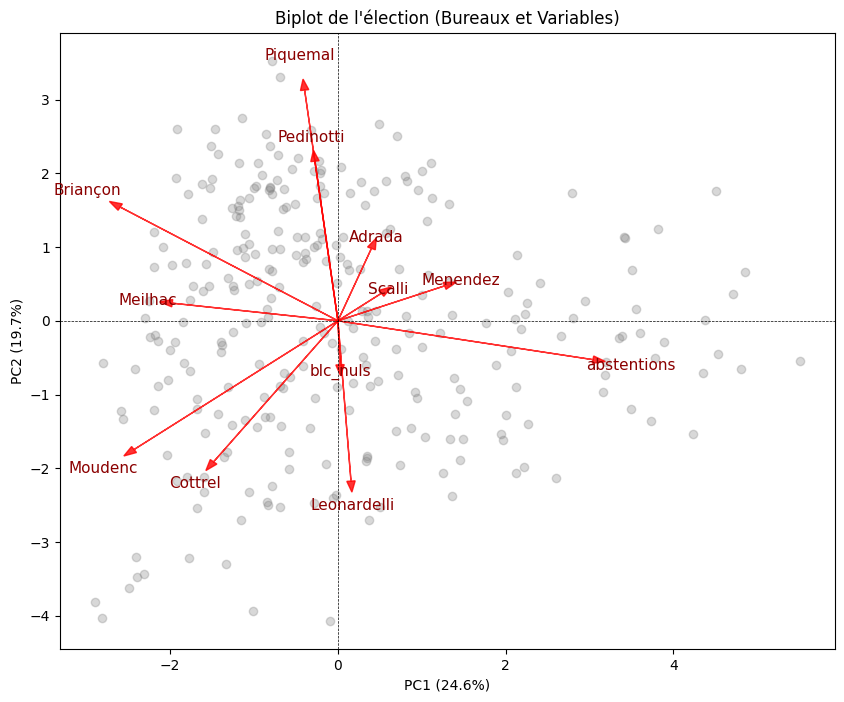

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, color='grey')

poids_pc1 = pca.components_[0]
poids_pc2 = pca.components_[1]

scale = np.max(np.abs(X_pca)) 

for i, variable in enumerate(colonnes_totales):
    ax.arrow(0, 0, poids_pc1[i] * scale, poids_pc2[i] * scale, 
             color='red', alpha=0.8, head_width=0.1)
    
    ax.text(poids_pc1[i] * scale * 1.15, poids_pc2[i] * scale * 1.15, 
            variable, color='darkred', ha='center', va='center', fontsize=11)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Biplot de l\'élection (Bureaux et Variables)')
plt.savefig('../plots/Biplot_premier_tour.png')

plt.show()

In [21]:
premier_tour['PC1'] = X_pca[:, 0]
premier_tour['PC2'] = X_pca[:, 1]

bureaux_extreme_droite_pc1 = premier_tour.nlargest(5, 'PC1')

bureaux_extreme_bas_pc2 = premier_tour.nsmallest(5, 'PC2')

colonnes_totales_analyse = colonnes_totales[:-1]

display(bureaux_extreme_droite_pc1[['bureau', 'PC1']])
display(bureaux_extreme_bas_pc2[['bureau', 'PC2']])


,bureau,PC1
134,0102,5.502648
78,0101,4.853543
198,0097,4.810274
196,0094,4.713333
132,0098,4.526769


,bureau,PC2
229,0252,-4.065985
272,0231,-4.031922
141,0147,-3.935380
227,0232,-3.813517
129,0063,-3.626621


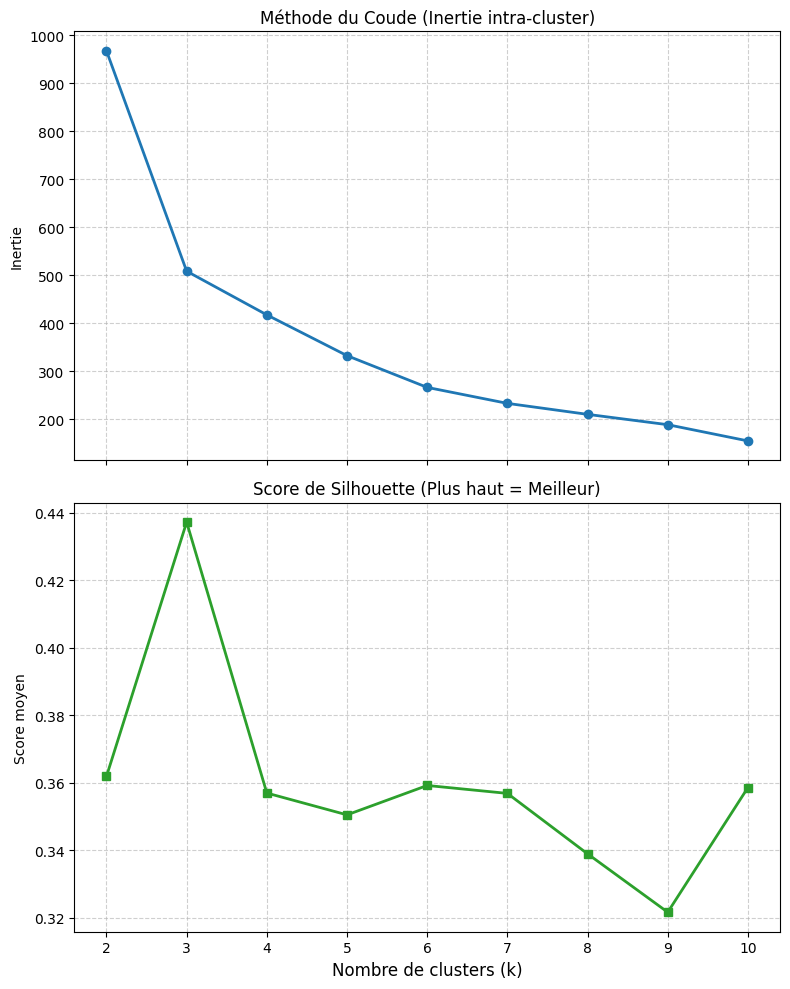

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    kmeans.fit(X_pca) 
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

ax1.plot(k_range, inertias, marker='o', linewidth=2, color='tab:blue')
ax1.set_title('Méthode du Coude (Inertie intra-cluster)', fontsize=12)
ax1.set_ylabel('Inertie')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='tab:green')
ax2.set_title('Score de Silhouette (Plus haut = Meilleur)', fontsize=12)
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [28]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = labels_clusters
premier_tour['Cluster_premier'] = labels_clusters

print("Nombre de bureaux par cluster :")
print(df['Cluster'].value_counts())

Nombre de bureaux par cluster :
Cluster
1    130
2     86
0     68
Name: count, dtype: int64


In [26]:
profils_clusters = df.groupby('Cluster')[colonnes_totales_analyse].mean()

display(profils_clusters.round(1))

,abstentions,Briançon,Scalli,Adrada,Menendez,Moudenc,Leonardelli,Cottrel,Meilhac,Piquemal,Pedinotti
Cluster,,,,,,,,,,,
0,59.7,8.1,0.2,0.2,0.2,13.2,3.2,0.5,0.5,13.1,0.5
1,39.1,16.5,0.2,0.3,0.1,19.5,2.3,0.6,1.0,19.1,0.7
2,39.2,14.0,0.1,0.2,0.1,28.1,3.8,1.0,1.1,11.2,0.4


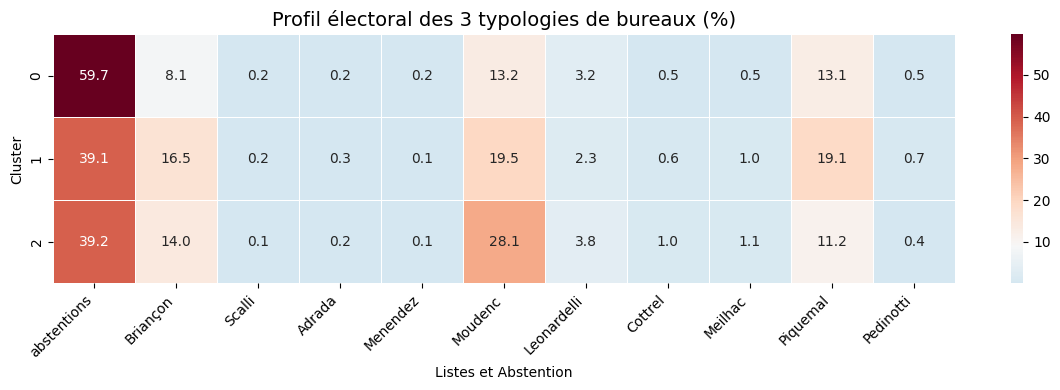

In [27]:
import seaborn as sns

plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 3 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../plots/Clusters_premier_tour.png')

plt.show()

# Analyse dynamique temporelle

In [51]:
df_fusion = pd.merge(premier_tour, deuxieme_tour, on = 'bureau')

In [52]:
print(df_fusion.columns)

Index(['Tour_x', 'bureau', 'inscrits_x', 'abstentions_x', 'votants_x',
       'votants_ap_emargement_x', 'blancs_x', 'nuls_x', 'exprimes_x',
       'Briançon', 'Scalli', 'Adrada', 'Menendez', 'Moudenc_x', 'Leonardelli',
       'Cottrel', 'Meilhac', 'Piquemal_x', 'Pedinotti', 'adresse_x',
       'Geo_Point_x', 'Geo_Shape_x', 'gml_id_x', 'infobulle_x', 'oid_x',
       'Nom_x', 'tx_participation_x', 'tx_nuls_blc_x', 'PC1', 'PC2',
       'Cluster_premier', 'Tour_y', 'inscrits_y', 'abstentions_y', 'votants_y',
       'votants_ap_emargement_y', 'blancs_y', 'nuls_y', 'exprimes_y',
       'Moudenc_y', 'Piquemal_y', 'adresse_y', 'Geo_Point_y', 'Geo_Shape_y',
       'gml_id_y', 'infobulle_y', 'oid_y', 'Nom_y', 'tx_participation_y',
       'tx_nuls_blc_y'],
      dtype='str')


In [53]:
columns_fusion_name = ['Tour', 'bureau', 'inscrits_premier', 'abstentions_premier', 'votants_premier',
       'votants_ap_emargement_premier', 'blancs_premier', 'nuls_premier', 'exprimes_premier',
       'Briançon', 'Scalli', 'Adrada', 'Menendez', 'Moudenc_premier', 'Leonardelli',
       'Cottrel', 'Meilhac', 'Piquemal_premier', 'Pedinotti', 'adresse_premier',
       'Geo_Point_premier', 'Geo_Shape_premier', 'gml_id_premier', 'infobulle_premier', 'oid_premier',
       'Nom_premier', 'tx_participation_premier', 'tx_nuls_blc_premier', 'PC1_premier', 'PC2_premier', 'Cluster_premier',
       'Tour_second', 'inscrits_second', 'abstentions_second', 'votants_second',
       'votants_ap_emargement_second', 'blancs_second', 'nuls_second', 'exprimes_second',
       'Moudenc_second', 'Piquemal_second', 'adresse_second', 'Geo_Point_second', 'Geo_Shape_second',
       'gml_id_second', 'infobulle_second', 'oid_second', 'Nom_second', 'tx_participation_second',
       'tx_nuls_blc_second']

df_fusion.columns = columns_fusion_name

df_fusion['Delta_Abstention'] = df_fusion['abstentions_second'] - df_fusion['abstentions_premier']
df_fusion['blc_nuls_premier'] = df_fusion['blancs_premier'] + df_fusion['nuls_premier']
df_fusion['blc_nuls_second'] = df_fusion['blancs_second'] + df_fusion['nuls_second']
df_fusion['Delta_Gauche'] = df_fusion['Piquemal_second'] - (df_fusion['Briançon'] + df_fusion['Piquemal_premier'])

df_fusion_cleaned = df_fusion.drop(columns=['Tour', 'Tour_second', 'bureau', 'votants_ap_emargement_premier', 'votants_ap_emargement_second', 
                                    'adresse_premier', 'Geo_Point_premier', 
                                    'Geo_Shape_premier', 'gml_id_premier', 
                                    'infobulle_premier', 'oid_premier', 'exprimes_premier', 'exprimes_second', 
                                    'Nom_premier', 'tx_participation_premier', 
                                    'adresse_second', 'votants_premier', 'votants_second', 
                                    'Geo_Point_second', 'Geo_Shape_second','tx_nuls_blc_premier', 'tx_nuls_blc_second',
                                    'gml_id_second', 'infobulle_second', 'blancs_premier', 'nuls_premier', 'blancs_second', 'nuls_second',
                                    'oid_second', 'Nom_second', 'tx_participation_second'])



In [38]:
listes_candidates_premier = df_fusion_cleaned.columns[1:11]
listes_candidates_second = df_fusion_cleaned.columns[16:19]

df_fusion_cleaned[listes_candidates_premier] = df_fusion_cleaned[listes_candidates_premier].div(df_fusion_cleaned['inscrits_premier'], axis=0) * 100
df_fusion_cleaned[listes_candidates_second] = df_fusion_cleaned[listes_candidates_second].div(df_fusion_cleaned['inscrits_second'], axis=0) * 100
df_fusion_cleaned['blc_nuls_premier'] = df_fusion_cleaned['blc_nuls_premier'] /df_fusion_cleaned['inscrits_premier'] *100
df_fusion_cleaned['blc_nuls_second'] = df_fusion_cleaned['blc_nuls_second'] /df_fusion_cleaned['inscrits_second'] *100

df_fusion_cleaned = df_fusion_cleaned.drop(columns=['inscrits_premier', 'inscrits_second', 'PC1_premier', 'PC2_premier', 'Cluster_premier'])

Variance expliquée par axe : [32.06769995 20.05697826]


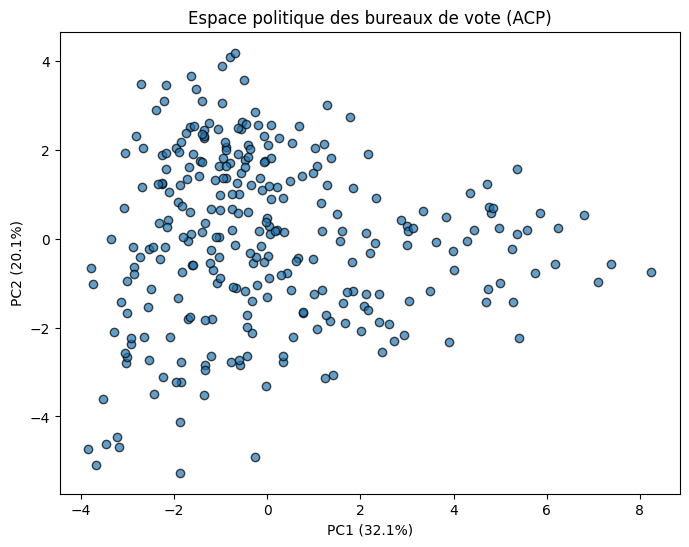

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_fusion_cleaned)

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par axe : {pca.explained_variance_ratio_ * 100}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Espace politique des bureaux de vote (ACP)')
plt.show()

In [40]:
colonnes_totales = df_fusion_cleaned.columns

df_loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=colonnes_totales  
)

print("--- Contributions à l'axe PC1 ---")
display(df_loadings.sort_values(by='PC1', ascending=False)['PC1'])

print("\n--- Contributions à l'axe PC2 ---")
display(df_loadings.sort_values(by='PC2', ascending=False)['PC2'])

--- Contributions à l'axe PC1 ---


abstentions_premier    0.403369
abstentions_second     0.403182
Delta_Gauche           0.366306
Menendez               0.126833
Delta_Abstention       0.070795
Scalli                 0.056284
Adrada                 0.030619
Leonardelli            0.003847
blc_nuls_premier      -0.009906
Piquemal_premier      -0.045076
Pedinotti             -0.064491
Piquemal_second       -0.088641
Cottrel               -0.183306
Meilhac               -0.225320
blc_nuls_second       -0.280056
Moudenc_premier       -0.327424
Moudenc_second        -0.339179
Briançon              -0.340796
Name: PC1, dtype: float64


--- Contributions à l'axe PC2 ---


Piquemal_second        0.494874
Piquemal_premier       0.483796
Pedinotti              0.278435
Briançon               0.238581
Delta_Abstention       0.134234
blc_nuls_second        0.127181
Adrada                 0.120058
Menendez               0.063211
Scalli                 0.056288
Meilhac                0.038489
Delta_Gauche           0.022771
abstentions_second    -0.056396
blc_nuls_premier      -0.067492
abstentions_premier   -0.084153
Cottrel               -0.261737
Moudenc_premier       -0.272188
Moudenc_second        -0.284786
Leonardelli           -0.300516
Name: PC2, dtype: float64

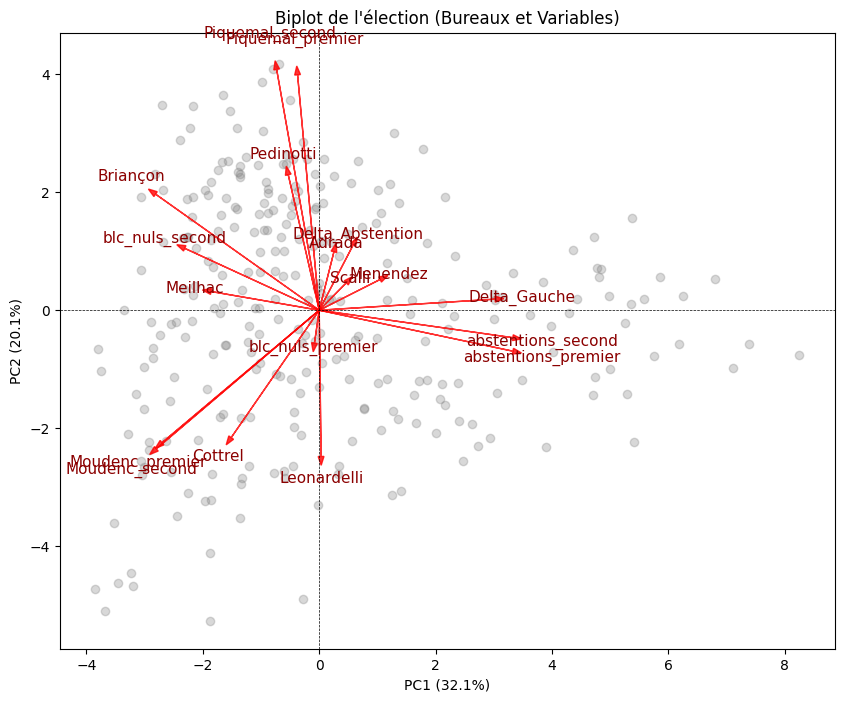

In [41]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, color='grey')

poids_pc1 = pca.components_[0]
poids_pc2 = pca.components_[1]

scale = np.max(np.abs(X_pca)) 

for i, variable in enumerate(colonnes_totales):
    ax.arrow(0, 0, poids_pc1[i] * scale, poids_pc2[i] * scale, 
             color='red', alpha=0.8, head_width=0.1)
    
    ax.text(poids_pc1[i] * scale * 1.15, poids_pc2[i] * scale * 1.15, 
            variable, color='darkred', ha='center', va='center', fontsize=11)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Biplot de l\'élection (Bureaux et Variables)')
plt.savefig('../plots/Biplot_second_tour.png')
plt.show()

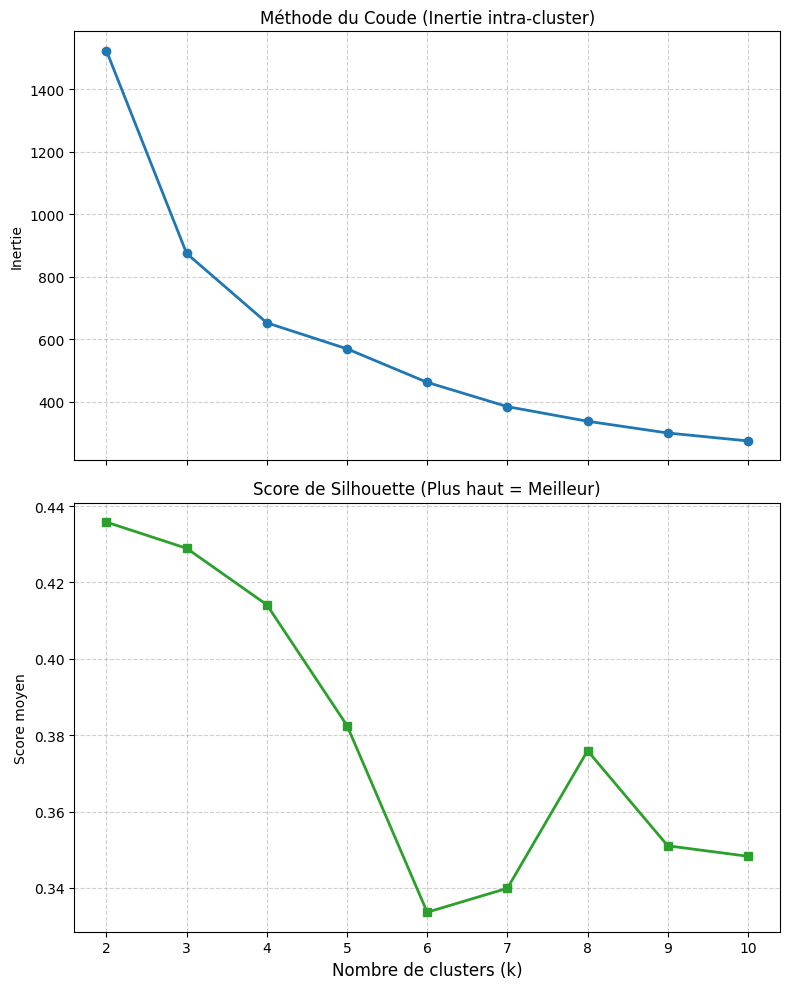

In [42]:
k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    kmeans.fit(X_pca) 
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

ax1.plot(k_range, inertias, marker='o', linewidth=2, color='tab:blue')
ax1.set_title('Méthode du Coude (Inertie intra-cluster)', fontsize=12)
ax1.set_ylabel('Inertie')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='tab:green')
ax2.set_title('Score de Silhouette (Plus haut = Meilleur)', fontsize=12)
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [54]:
df_fusion['PC1'] = X_pca[:, 0]
df_fusion['PC2'] = X_pca[:, 1]

bureaux_extreme_droite_pc1 = df_fusion.nlargest(5, 'PC1')

bureaux_extreme_bas_pc2 = df_fusion.nsmallest(5, 'PC2')

colonnes_totales_analyse = colonnes_totales[:-1]

display(bureaux_extreme_droite_pc1[['bureau', 'PC1']])
display(bureaux_extreme_bas_pc2[['bureau', 'PC2']])

,bureau,PC1
134,0102,8.250695
132,0098,7.387652
198,0097,7.104439
78,0101,6.801594
14,0071,6.245987


,bureau,PC2
141,0147,-5.264590
272,0231,-5.099903
229,0252,-4.902005
227,0232,-4.724380
271,0229,-4.678385


In [64]:
print(df_fusion.columns)
print(df_fusion.columns[3:19])
print(df_fusion.columns[33:41])

Index(['Tour', 'bureau', 'inscrits_premier', 'abstentions_premier',
       'votants_premier', 'votants_ap_emargement_premier', 'blancs_premier',
       'nuls_premier', 'exprimes_premier', 'Briançon', 'Scalli', 'Adrada',
       'Menendez', 'Moudenc_premier', 'Leonardelli', 'Cottrel', 'Meilhac',
       'Piquemal_premier', 'Pedinotti', 'adresse_premier', 'Geo_Point_premier',
       'Geo_Shape_premier', 'gml_id_premier', 'infobulle_premier',
       'oid_premier', 'Nom_premier', 'tx_participation_premier',
       'tx_nuls_blc_premier', 'PC1_premier', 'PC2_premier', 'Cluster_premier',
       'Tour_second', 'inscrits_second', 'abstentions_second',
       'votants_second', 'votants_ap_emargement_second', 'blancs_second',
       'nuls_second', 'exprimes_second', 'Moudenc_second', 'Piquemal_second',
       'adresse_second', 'Geo_Point_second', 'Geo_Shape_second',
       'gml_id_second', 'infobulle_second', 'oid_second', 'Nom_second',
       'tx_participation_second', 'tx_nuls_blc_second', 'Delta

In [56]:
df_test = df_fusion

In [65]:
listes_candidates_premier = df_fusion.columns[3:19]
listes_candidates_second = df_fusion.columns[33:41]

df_fusion[listes_candidates_premier] = df_fusion[listes_candidates_premier].div(df_fusion['inscrits_premier'], axis=0) * 100
df_fusion[listes_candidates_second] = df_fusion[listes_candidates_second].div(df_fusion['inscrits_second'], axis=0) * 100

Nombre de bureaux par cluster :
Cluster_3
1    125
2     92
0     67
Name: count, dtype: int64


,abstentions_premier,Briançon,Scalli,Adrada,Menendez,Moudenc_premier,Leonardelli,Cottrel,Meilhac,Piquemal_premier,Pedinotti,abstentions_second,Moudenc_second,Piquemal_second,Delta_Abstention,blc_nuls_premier,blc_nuls_second
Cluster_3,,,,,,,,,,,,,,,,,
0,59.9,8.2,0.2,0.2,0.2,12.7,3.2,0.5,0.5,13.2,0.5,53.7,21.4,23.9,-55.5,6.0,9.7
1,38.8,16.6,0.2,0.3,0.1,19.4,2.4,0.6,1.0,19.3,0.7,33.3,30.7,34.0,-57.7,7.2,21.2
2,39.6,13.9,0.1,0.2,0.1,28.0,3.7,1.0,1.1,11.2,0.4,32.9,43.0,22.3,-66.2,7.1,17.7


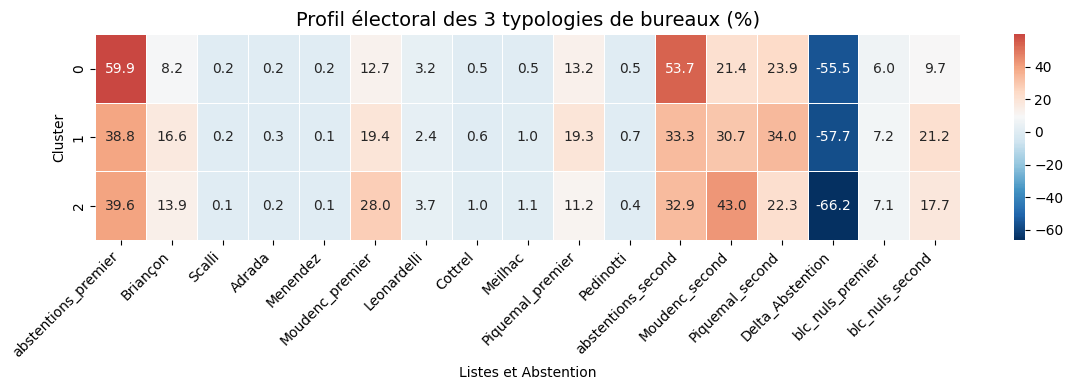

In [66]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

df_fusion['Cluster_3'] = labels_clusters

print("Nombre de bureaux par cluster :")
print(df_fusion['Cluster_3'].value_counts())

profils_clusters = df_fusion.groupby('Cluster_3')[colonnes_totales_analyse].mean()
display(profils_clusters.round(1))

plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 3 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/Cluster_3.png')

plt.show()

Nombre de bureaux par cluster :
Cluster_8
1    52
2    48
0    43
6    39
5    32
4    31
7    30
3     9
Name: count, dtype: int64


,abstentions_premier,Briançon,Scalli,Adrada,Menendez,Moudenc_premier,Leonardelli,Cottrel,Meilhac,Piquemal_premier,Pedinotti,abstentions_second,Moudenc_second,Piquemal_second,Delta_Abstention,blc_nuls_premier,blc_nuls_second
Cluster_8,,,,,,,,,,,,,,,,,
0,50.7,10.6,0.2,0.2,0.1,19.3,4.9,0.8,0.9,11.1,0.5,44.7,32.8,21.1,-61.5,7.4,14.3
1,35.4,18.2,0.1,0.2,0.1,19.5,2.0,0.6,1.0,21.3,0.7,30.1,30.6,37.1,-58.0,7.9,24.2
2,36.8,16.6,0.1,0.2,0.0,25.5,2.9,0.9,1.1,14.6,0.5,30.4,39.7,27.9,-61.8,7.1,19.8
3,72.4,4.0,0.1,0.1,0.1,7.8,1.3,0.2,0.2,13.0,0.3,64.1,11.4,23.8,-77.6,4.2,5.8
4,61.7,7.6,0.2,0.2,0.2,11.2,2.7,0.4,0.4,14.1,0.5,55.7,18.3,25.0,-47.7,6.1,8.3
5,36.1,13.2,0.1,0.1,0.1,34.8,3.3,1.2,1.0,9.0,0.3,28.7,50.9,18.7,-72.7,7.2,17.4
6,43.1,15.1,0.2,0.2,0.1,17.4,2.1,0.5,1.1,19.0,0.7,37.5,28.0,32.9,-55.9,4.7,15.7
7,44.0,14.3,0.3,0.5,0.1,19.2,3.5,0.5,0.9,15.2,0.7,38.2,31.2,28.6,-56.8,8.0,20.7


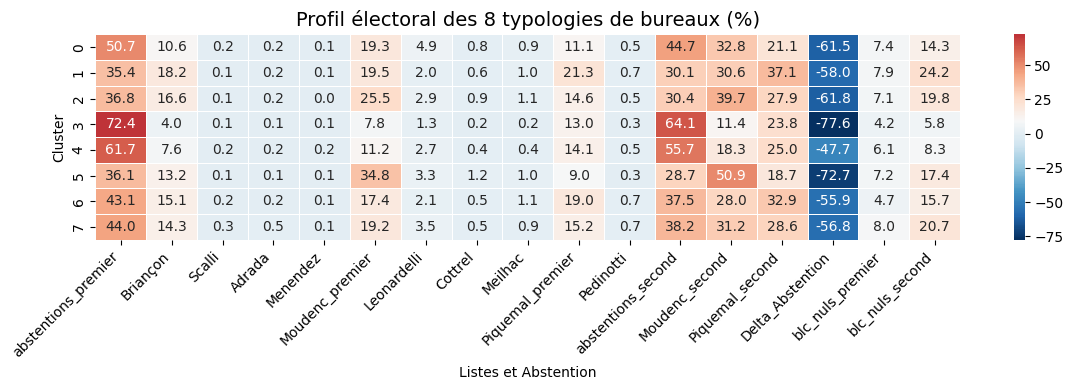

In [67]:
kmeans_final = KMeans(n_clusters=8, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

df_fusion['Cluster_8'] = labels_clusters

print("Nombre de bureaux par cluster :")
print(df_fusion['Cluster_8'].value_counts())

profils_clusters = df_fusion.groupby('Cluster_8')[colonnes_totales_analyse].mean()
display(profils_clusters.round(1))

plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 8 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/Clusters_8.png')

plt.show()

# Analyse Spatiale des résultats

In [68]:
print(df_fusion.columns)

Index(['Tour', 'bureau', 'inscrits_premier', 'abstentions_premier',
       'votants_premier', 'votants_ap_emargement_premier', 'blancs_premier',
       'nuls_premier', 'exprimes_premier', 'Briançon', 'Scalli', 'Adrada',
       'Menendez', 'Moudenc_premier', 'Leonardelli', 'Cottrel', 'Meilhac',
       'Piquemal_premier', 'Pedinotti', 'adresse_premier', 'Geo_Point_premier',
       'Geo_Shape_premier', 'gml_id_premier', 'infobulle_premier',
       'oid_premier', 'Nom_premier', 'tx_participation_premier',
       'tx_nuls_blc_premier', 'PC1_premier', 'PC2_premier', 'Cluster_premier',
       'Tour_second', 'inscrits_second', 'abstentions_second',
       'votants_second', 'votants_ap_emargement_second', 'blancs_second',
       'nuls_second', 'exprimes_second', 'Moudenc_second', 'Piquemal_second',
       'adresse_second', 'Geo_Point_second', 'Geo_Shape_second',
       'gml_id_second', 'infobulle_second', 'oid_second', 'Nom_second',
       'tx_participation_second', 'tx_nuls_blc_second', 'Delta

In [95]:
df = df_fusion.drop(columns=['adresse_premier', 'Geo_Point_premier',
       'Geo_Shape_premier', 'gml_id_premier', 'infobulle_premier',
       'oid_premier', 'Nom_premier', 'adresse_second', 'Geo_Point_second', 'Geo_Shape_second',
       'gml_id_second', 'infobulle_second', 'oid_second', 'Nom_second'])

In [96]:
print(df.columns)
print(df.columns[3:19])
print(df.columns[26:34])

Index(['Tour', 'bureau', 'inscrits_premier', 'abstentions_premier',
       'votants_premier', 'votants_ap_emargement_premier', 'blancs_premier',
       'nuls_premier', 'exprimes_premier', 'Briançon', 'Scalli', 'Adrada',
       'Menendez', 'Moudenc_premier', 'Leonardelli', 'Cottrel', 'Meilhac',
       'Piquemal_premier', 'Pedinotti', 'tx_participation_premier',
       'tx_nuls_blc_premier', 'PC1_premier', 'PC2_premier', 'Cluster_premier',
       'Tour_second', 'inscrits_second', 'abstentions_second',
       'votants_second', 'votants_ap_emargement_second', 'blancs_second',
       'nuls_second', 'exprimes_second', 'Moudenc_second', 'Piquemal_second',
       'tx_participation_second', 'tx_nuls_blc_second', 'Delta_Abstention',
       'blc_nuls_premier', 'blc_nuls_second', 'Delta_Gauche', 'PC1', 'PC2',
       'Cluster_3', 'Cluster_8'],
      dtype='str')
Index(['abstentions_premier', 'votants_premier',
       'votants_ap_emargement_premier', 'blancs_premier', 'nuls_premier',
       'exprime

In [97]:
import geopandas as gpd

gdf_bureaux = gpd.read_file("../data/raw/election-2026-lieux-de-vote.geojson")

gdf_bureaux['bureau'] = gdf_bureaux['bureau'].astype(str).str.zfill(4)

gdf_analyse = gdf_bureaux.merge(df, on='bureau')

print(f"Bureaux dans le fond de carte : {len(gdf_bureaux)}")
print(f"Bureaux après fusion : {len(gdf_analyse)}")


Bureaux dans le fond de carte : 284
Bureaux après fusion : 284


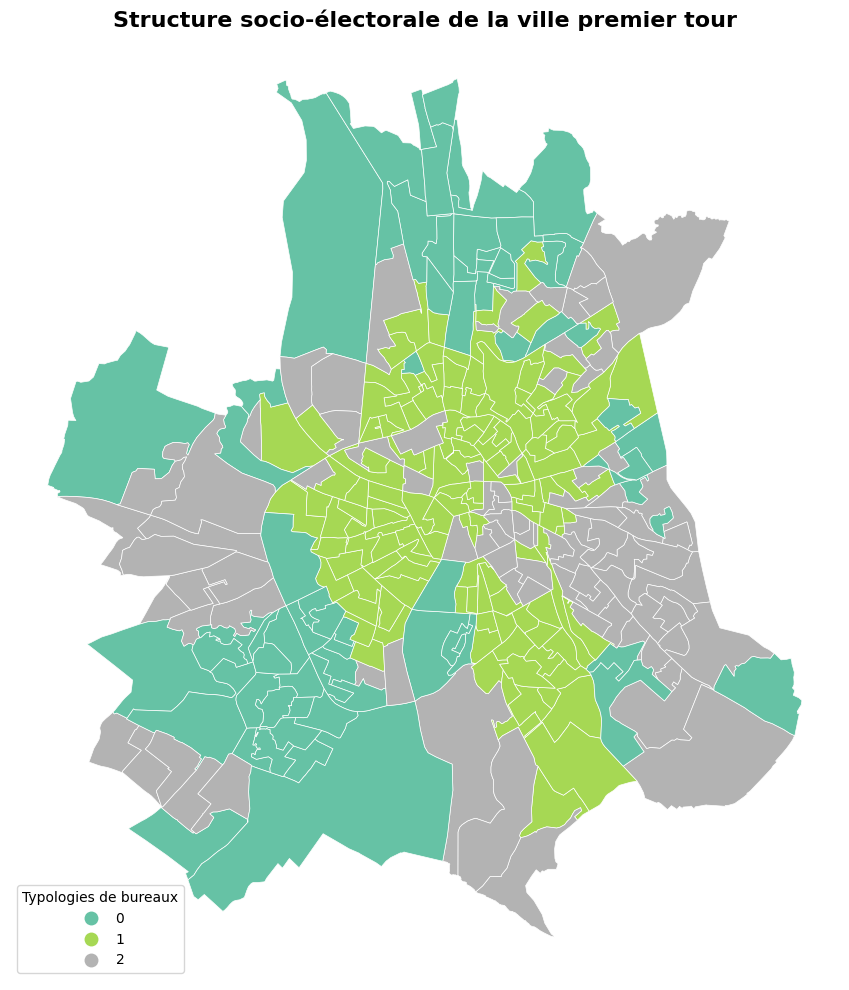

In [98]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Cluster_premier', 
    categorical=True, 
    legend=True, 
    cmap='Set2', 
    edgecolor='white', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'title': "Typologies de bureaux", 'loc': 'lower left'}
)

ax.set_title("Structure socio-électorale de la ville premier tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Clusters_map_premier_tour.png')

plt.show()

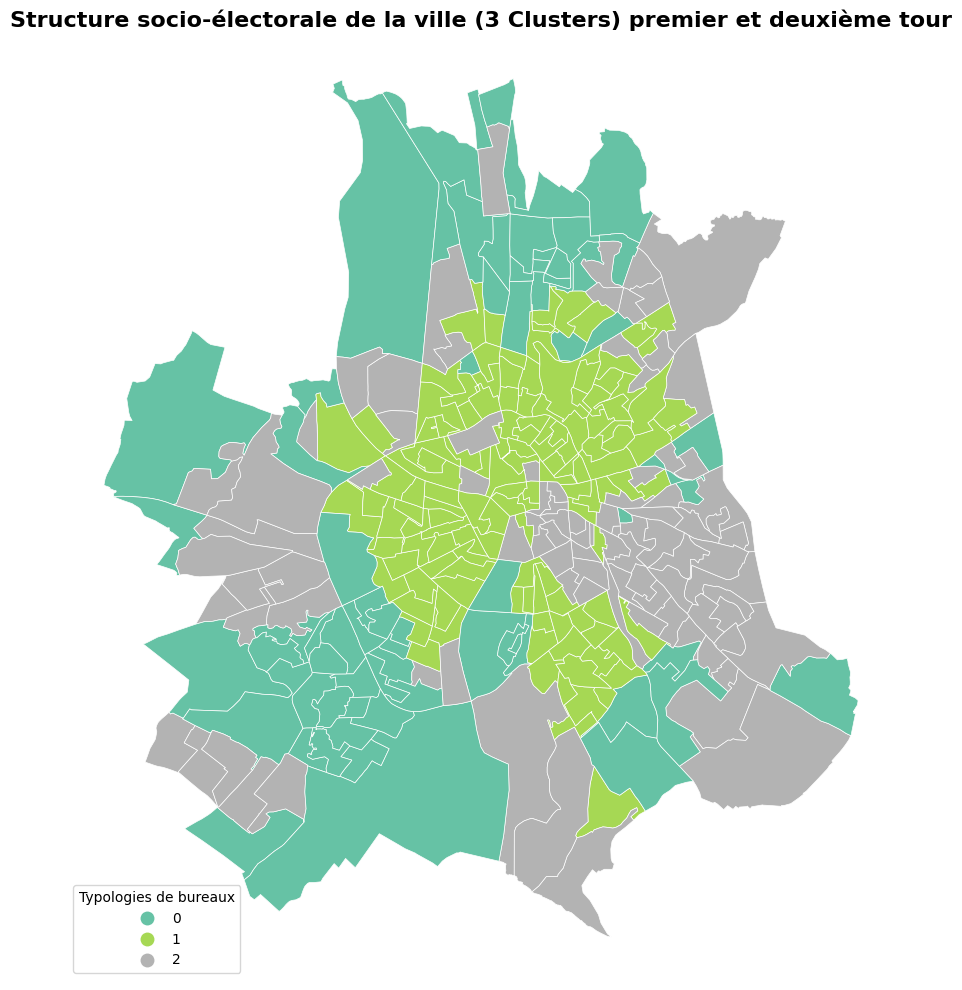

In [99]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Cluster_3', 
    categorical=True, 
    legend=True, 
    cmap='Set2', 
    edgecolor='white', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'title': "Typologies de bureaux", 'loc': 'lower left'}
)

ax.set_title("Structure socio-électorale de la ville (3 Clusters) premier et deuxième tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Clusters_3_joined_map.png')
plt.show()

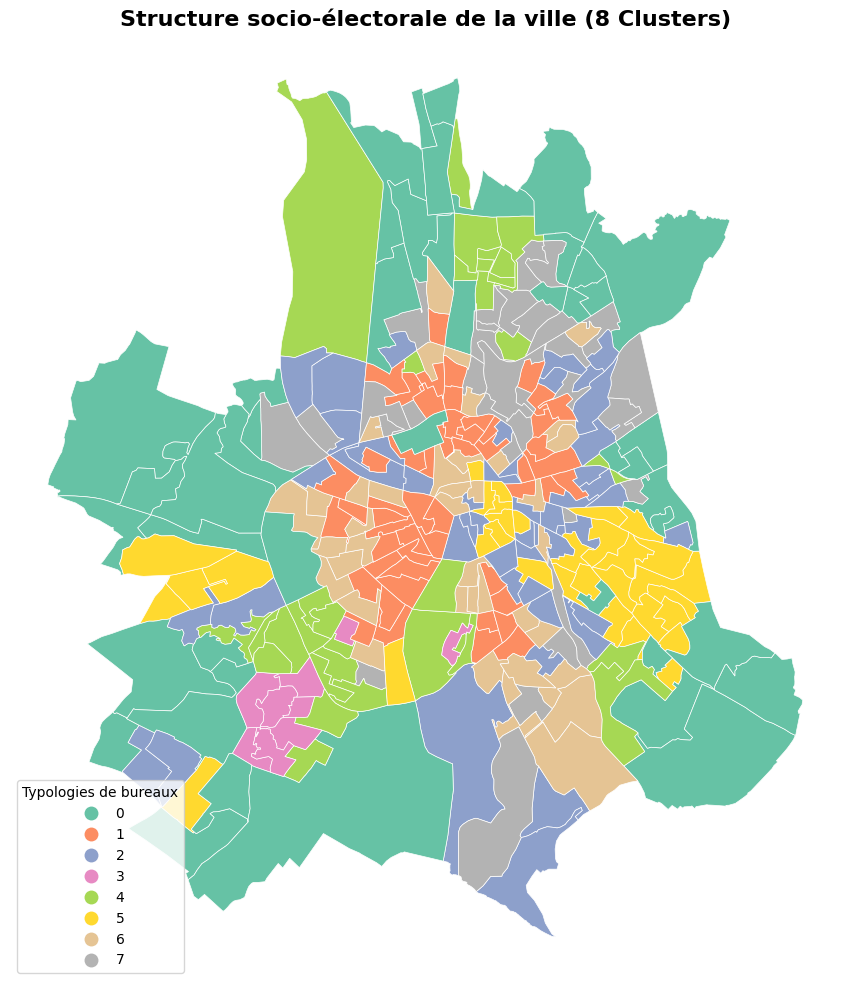

In [100]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Cluster_8', 
    categorical=True, 
    legend=True, 
    cmap='Set2', 
    edgecolor='white', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'title': "Typologies de bureaux", 'loc': 'lower left'}
)

ax.set_title("Structure socio-électorale de la ville (8 Clusters)", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Clusters_8_map.png')
plt.show()

In [101]:
from libpysal.weights import Queen
from esda.moran import Moran

w = Queen.from_dataframe(gdf_analyse, use_index=False)
w.transform = 'R'

variable_cible = gdf_analyse['abstentions_premier']
mi = Moran(variable_cible, w)

print(f"Indice I de Moran : {mi.I:.4f}")
print(f"p-value du test de permutation : {mi.p_sim:.4f}")

Indice I de Moran : 0.5741
p-value du test de permutation : 0.0010


In [102]:
display(gdf_analyse['abstentions_premier'].head())

0    60.000000
1    38.436745
2    34.269119
3    39.033124
4    74.333801
Name: abstentions_premier, dtype: float64

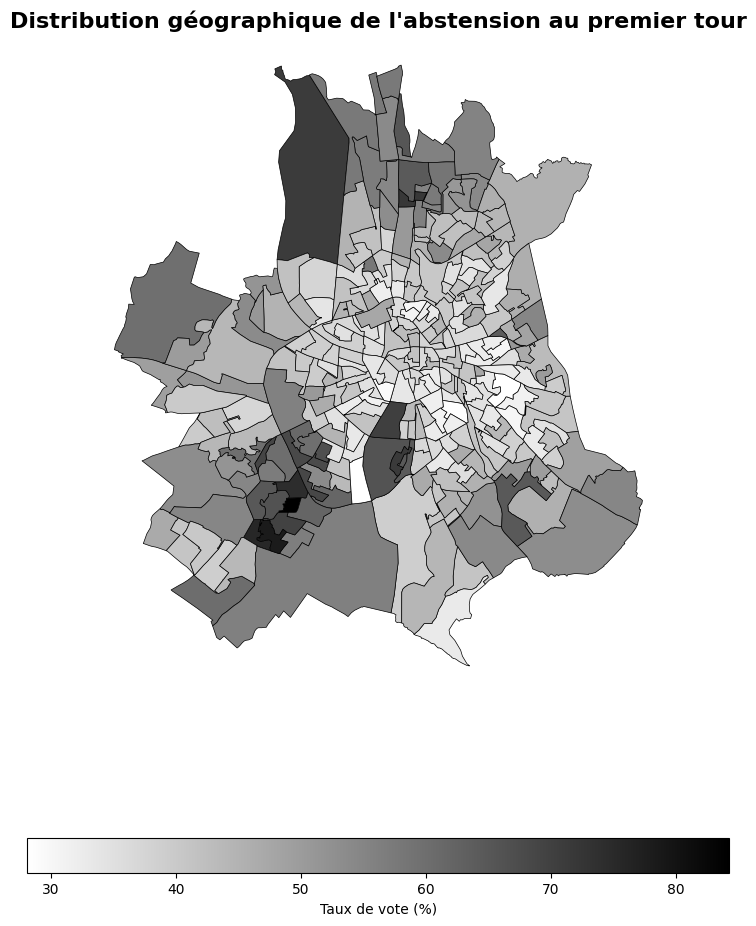

In [104]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='abstentions_premier', 
    categorical=False,
    legend=True, 
    cmap='binary', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique de l'abstension au premier tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Abstentions_map_premier_tour.png')

plt.show()

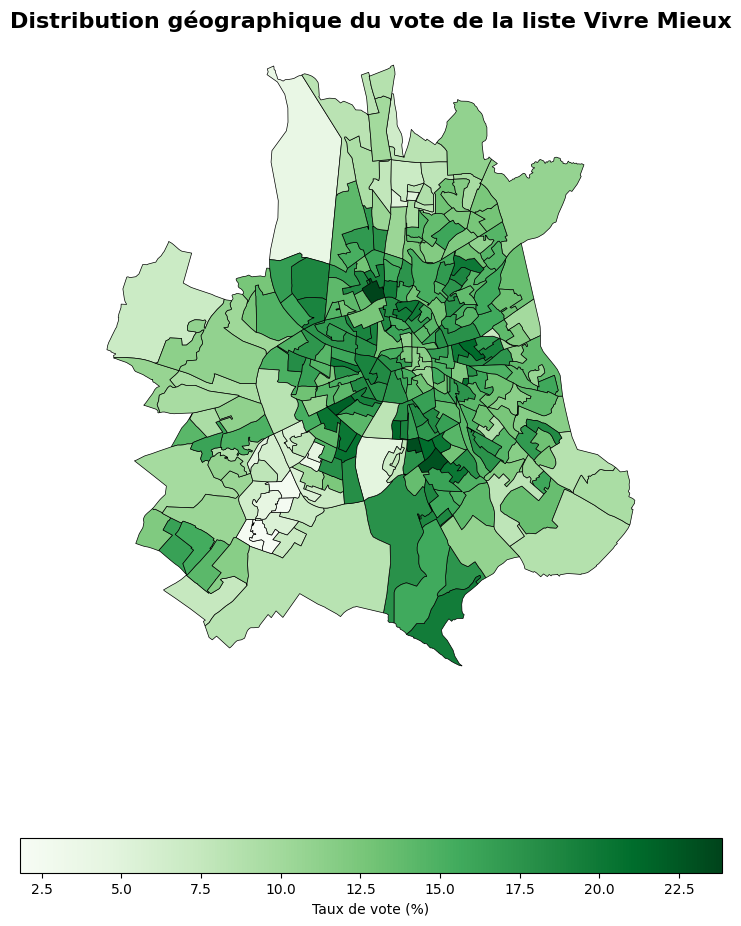

In [106]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Briançon', 
    categorical=False, 
    legend=True, 
    cmap='Greens', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Vivre Mieux", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Vivre_mieux_map_premier_tour.png')

plt.show()

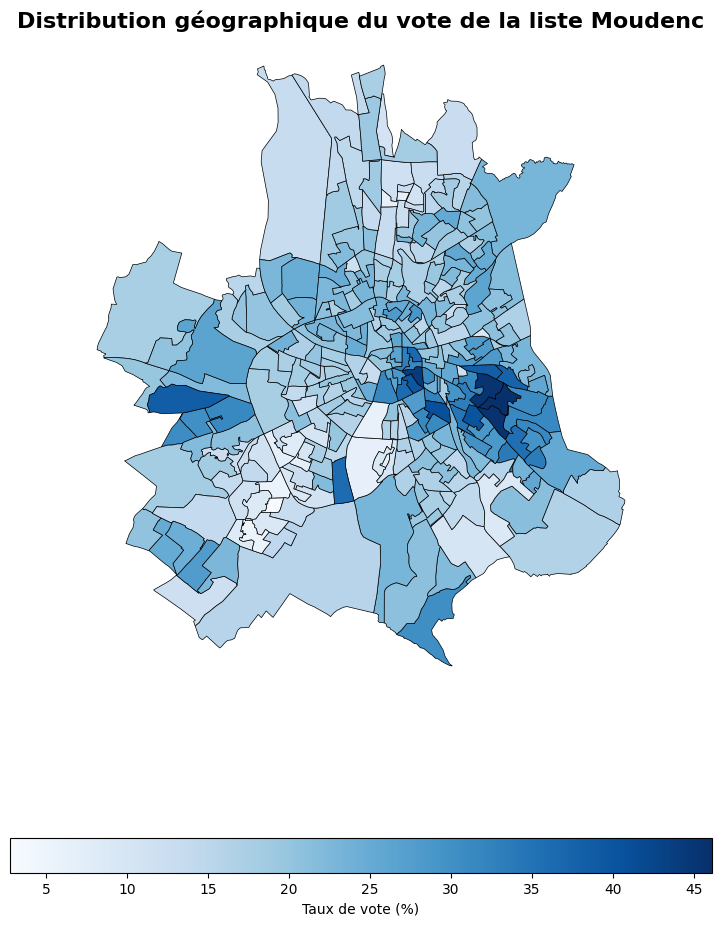

In [107]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Moudenc_premier', 
    categorical=False, 
    legend=True, 
    cmap='Blues', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Moudenc", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Moudenc_map_premier_tour.png')

plt.show()

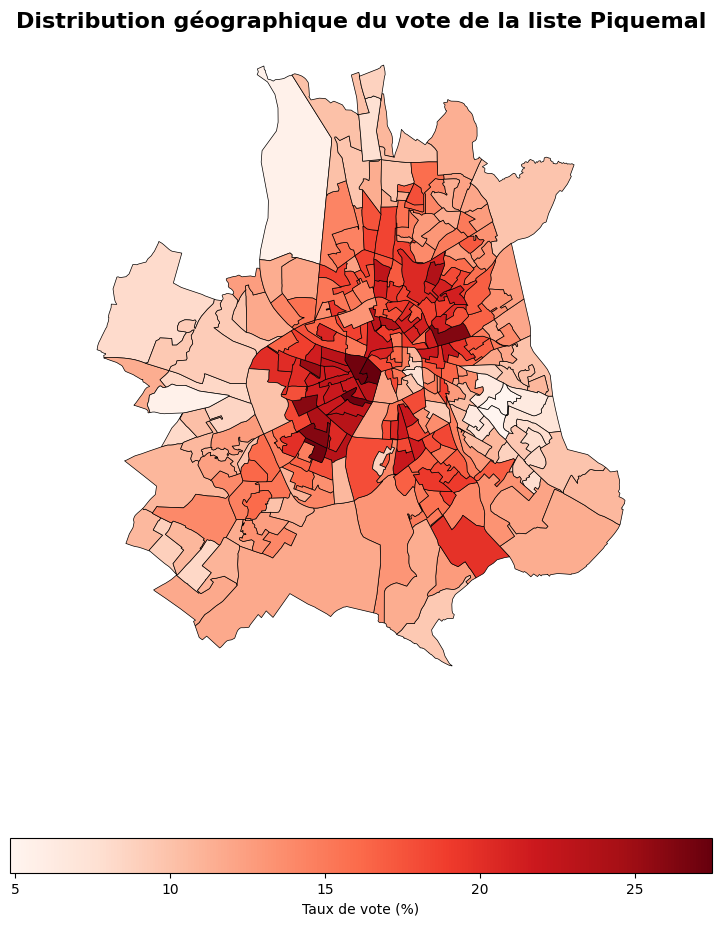

In [108]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Piquemal_premier', 
    categorical=False, 
    legend=True, 
    cmap='Reds', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Piquemal", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Piquemal_map_premier_tour.png')

plt.show()

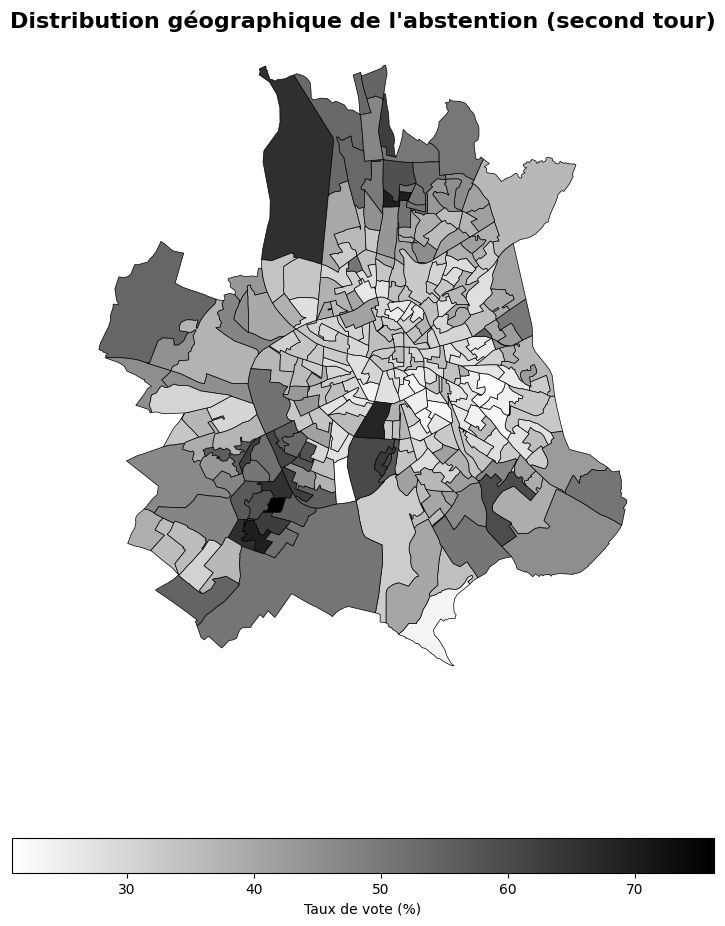

In [109]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='abstentions_second', 
    categorical=False, 
    legend=True, 
    cmap='binary', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique de l'abstention (second tour)", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Abstentions_map_deuxieme_tour.png')

plt.show()

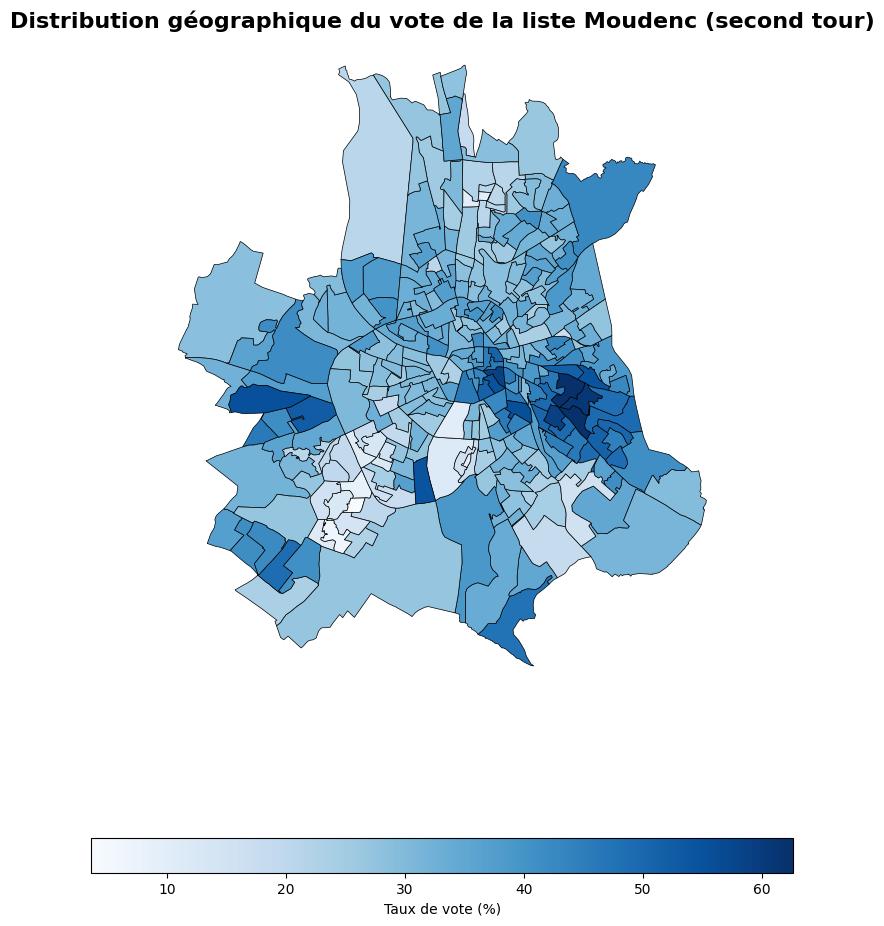

In [110]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Moudenc_second', 
    categorical=False, 
    legend=True, 
    cmap='Blues', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Moudenc (second tour)", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Moudenc_map_deuxieme_tour.png')

plt.show()

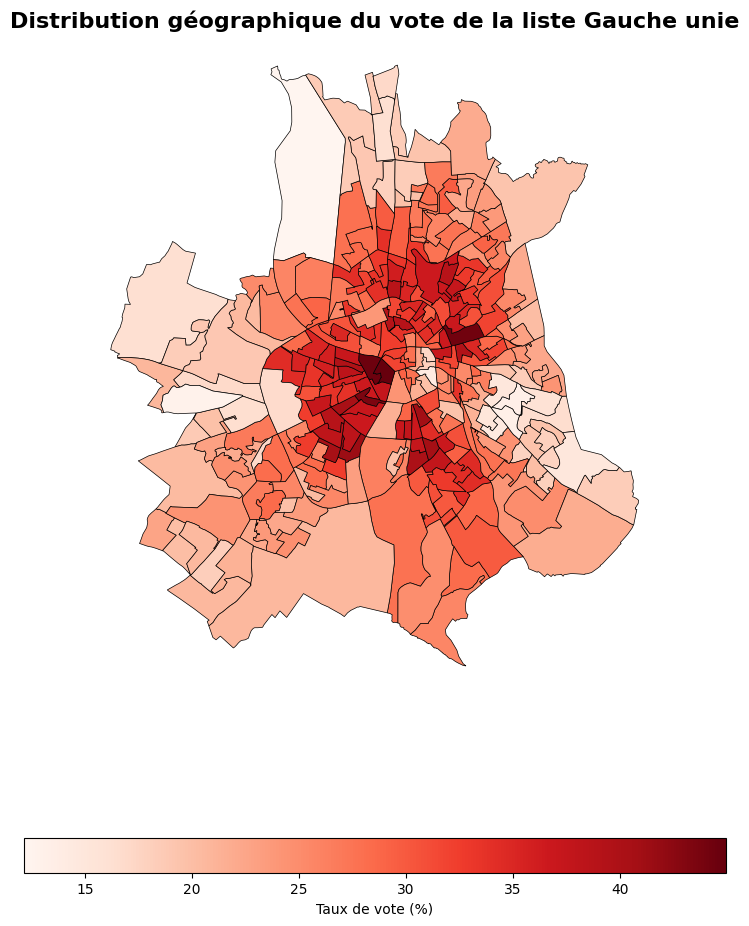

In [111]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Piquemal_second', 
    categorical=False, 
    legend=True, 
    cmap='Reds', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Gauche unie", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Gauche_unie_map_deuxieme_tour.png')

plt.show()

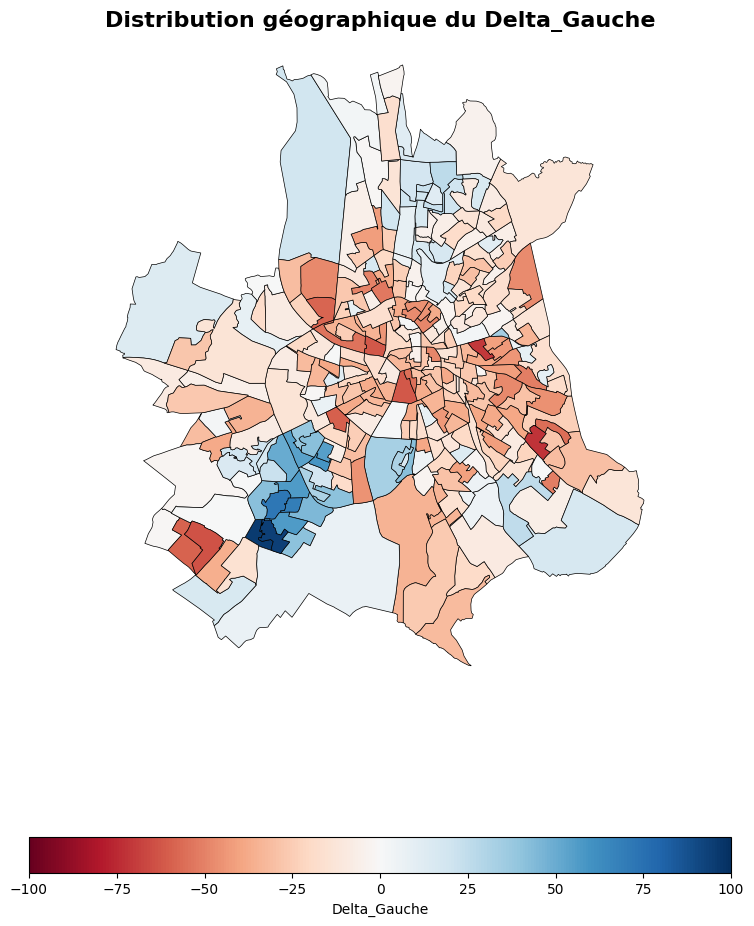

In [116]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Delta_Gauche', 
    categorical=False, vmin = -100, vmax = 100,
    legend=True, 
    cmap='RdBu', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Delta_Gauche", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du Delta_Gauche", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Delta_gauche_map.png')

plt.show()

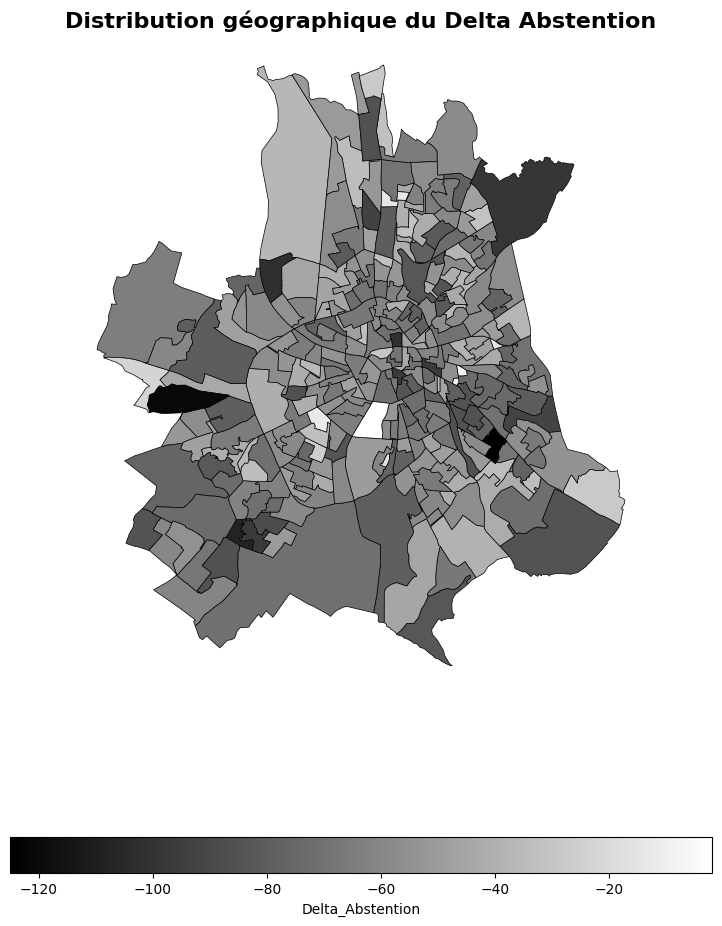

In [121]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_analyse.plot(
    column='Delta_Abstention',
    categorical=False, 
    legend=True, 
    cmap='gray', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Delta_Abstention", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du Delta Abstention", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Delta_Abstention_map.png')

plt.show()